# **Linear Regression**

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#load data
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
#explore data
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nStatistical summary:\n")
df.describe()

Shape: (20640, 9)

Missing values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical summary:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
#separate features and targets
X = df.drop("MedHouseVal", axis=1)   # features
y = df["MedHouseVal"]                # target (what we're predicting)

print(X.shape, y.shape)

(20640, 8) (20640,)


In [ ]:
#train, test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16512, 8)
Test size: (4128, 8)


In [ ]:
#training linear regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test) #storing predictions

In [ ]:
#evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression -> MSE: {mse_lr:.4f}, MAE: {mae_lr:.4f}, R²: {r2_lr:.4f}")

Linear Regression -> MSE: 0.5559, MAE: 0.5332, R²: 0.5758


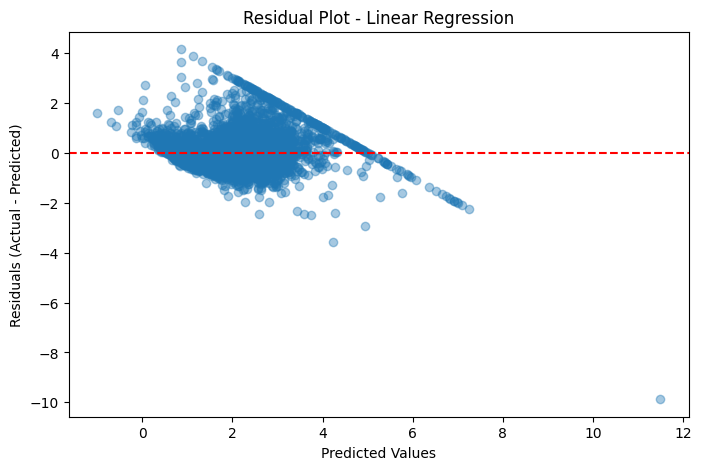

In [ ]:
#plot residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))
plt.scatter(y_pred_lr, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Linear Regression")
plt.show()

In [ ]:
#Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"Ridge -> MSE: {mse_ridge:.4f}, MAE: {mae_ridge:.4f}")

Ridge -> MSE: 0.5558, MAE: 0.5332


In [ ]:
#Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"Lasso -> MSE: {mse_lasso:.4f}, MAE: {mae_lasso:.4f}")

Lasso -> MSE: 0.6135, MAE: 0.5816


In [ ]:
# Compare Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso
0,MedInc,0.448675,0.448511,0.392693
1,HouseAge,0.009724,0.009726,0.015081
2,AveRooms,-0.123323,-0.123014,-0.000000
3,AveBedrms,0.783145,0.781417,0.000000
4,Population,-0.000002,-0.000002,0.000016
5,AveOccup,-0.003526,-0.003526,-0.003149
6,Latitude,-0.419792,-0.419787,-0.114291
7,Longitude,-0.433708,-0.433681,-0.099308


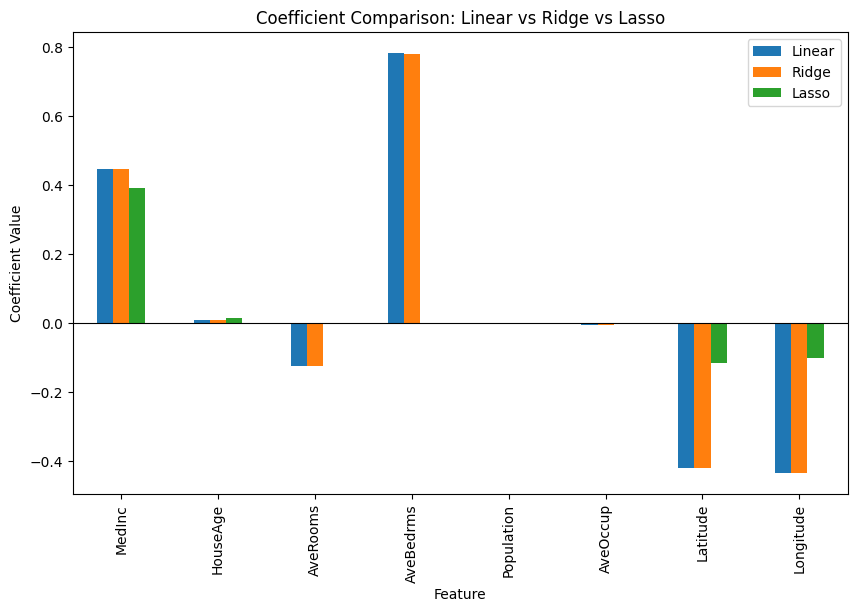

In [ ]:
coef_df.set_index("Feature").plot(kind="bar", figsize=(10,6))
plt.title("Coefficient Comparison: Linear vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")
plt.axhline(y=0, color='black', linewidth=0.8)
plt.show()

In [ ]:
#Final Comparison Summary
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "MSE": [mse_lr, mse_ridge, mse_lasso],
    "MAE": [mae_lr, mae_ridge, mae_lasso]
})

results

,Model,MSE,MAE
0,Linear Regression,0.555892,0.533200
1,Ridge,0.555803,0.533204
2,Lasso,0.613512,0.581607
